# Extract Recovered Symbolic Model

In [5]:
import sympy as sp
import torch
import dill
from pathlib import Path

# ------------------------------------------------------------
# Load model
# ------------------------------------------------------------
SAVE_PATH = Path("models/frf_model_full.pt")
device = "cpu"

ckpt = torch.load(
    SAVE_PATH,
    map_location=device,
    pickle_module=dill,
    weights_only=False,
)

model = ckpt["model"].to(device)
model.eval()

feature_tokens = ckpt["feature_tokens"]
test_mse = ckpt["test_mse"]
expr_str = ckpt["expr"]

# ------------------------------------------------------------
# symbolic variables exactly as in training
# ------------------------------------------------------------
omega = sp.Symbol("omega")
phi = sp.Symbol("phi")
damage = sp.Symbol("d")

name_map = {
    "f": omega,
    "sin_phase": sp.sin(phi),
    "cos_phase": sp.cos(phi),
    "damage": damage,
}

symbolic_inputs = [name_map[t] for t in feature_tokens]
omega = name_map["f"]
aux_inputs = symbolic_inputs[1:]

# ------------------------------------------------------------
# helper
# ------------------------------------------------------------
def coef(w: torch.Tensor, decimals: int = 5):
    return round(float(w.real.detach().cpu().item()), decimals)

# ------------------------------------------------------------
# build expression manually
# ------------------------------------------------------------
a = coef(model.a)
b = coef(model.b)

expr = a * omega + b

for block in model.resonators:
    A = coef(block.A)
    gamma = coef(block.gamma)

    h = block.eql.get_symbolic_expression(
        aux_inputs,
        rounding_decimals=5,
        use_imag=False,
    )

    expr = expr + A / ((omega - h) ** 2 + gamma)

# ------------------------------------------------------------
# build equation
# ------------------------------------------------------------
Hhat = sp.Function(r"\hat{H}")
lhs = Hhat(*symbolic_inputs)
eq = sp.Eq(lhs, expr)

# ------------------------------------------------------------
# output
# ------------------------------------------------------------
print("Feature tokens:", feature_tokens)
print("Test MSE:", test_mse)

print("\nCheckpoint expr string:")
print(expr_str)

print("\nRebuilt symbolic expression:")
print(expr)

print("\nEquation:")
print(eq)

print("\nLaTeX:\n")
print(r"\begin{equation}")
print(sp.latex(eq))
print(r"\end{equation}")

Feature tokens: ['f', 'sin_phase', 'cos_phase', 'damage']
Test MSE: 11.786767959594727

Checkpoint expr string:
-4.60734*omega + 10.31112 + 10.18736/(1.0*omega**2 - 0.48548*omega*sin(phi)**2 + 0.17266*omega*sin(phi) - 2.33172*omega + 0.05892*sin(phi)**4 - 0.04191*sin(phi)**3 + 0.57345*sin(phi)**2 - 0.2013*sin(phi) + 1.04506) - 0.20292/(0.0007*d**6 + 0.05292*d**3*omega - 0.01612*d**3 + 1.0*omega**2 - 0.6092*omega - 0.03467) + 8.4464/(1.0*omega**2 + 0.27322*omega*sin(phi) + 0.01866*sin(phi)**2 - 0.43614) - 0.17022/(0.0012*d**2 - 0.06928*d*omega + 1.0*omega**2 + 0.47071) - 0.40355/(1.0*omega**2 - 0.25292*omega - 1.0686)

Rebuilt symbolic expression:
-4.60734*omega + 10.31112 + 10.18736/((omega - 0.24274*sin(phi)**2 + 0.08633*sin(phi) - 1.16586)**2 - 0.31417) - 0.20292/((0.02646*d**3 + omega - 0.3046)**2 - 0.12746) + 8.4464/((omega + 0.13661*sin(phi))**2 - 0.43614) - 0.40355/((omega - 0.12646)**2 - 1.08459) - 0.17022/((-0.03464*d + omega)**2 + 0.47071)

Equation:
Eq(\hat{H}(omega, sin(phi)

In [6]:
eq

Eq(\hat{H}(omega, sin(phi), cos(phi), d), -4.60734*omega + 10.31112 + 10.18736/((omega - 0.24274*sin(phi)**2 + 0.08633*sin(phi) - 1.16586)**2 - 0.31417) - 0.20292/((0.02646*d**3 + omega - 0.3046)**2 - 0.12746) + 8.4464/((omega + 0.13661*sin(phi))**2 - 0.43614) - 0.40355/((omega - 0.12646)**2 - 1.08459) - 0.17022/((-0.03464*d + omega)**2 + 0.47071))

In [7]:
import sympy as sp

# ------------------------------------------------------------
# symbolic variables consistent with training
# ------------------------------------------------------------
phi = sp.Symbol("phi")
damage = sp.Symbol("d")

symbol_map = {
    "sin_phase": sp.sin(phi),
    "cos_phase": sp.cos(phi),
    "damage": damage,
}

symbolic_inputs_aux = [
    symbol_map["sin_phase"],
    symbol_map["cos_phase"],
    symbol_map["damage"],
]

# ------------------------------------------------------------
# print symbolic g_i functions
# ------------------------------------------------------------
for i, block in enumerate(model.resonators, start=1):

    g_expr = block.eql.get_symbolic_expression(
        symbolic_inputs_aux,
        rounding_decimals=5,
        use_imag=False,
    )

    print(f"g_{i} = {g_expr}\n")

    latex_expr = sp.latex(g_expr)

    print("LaTeX:")
    print(rf"g_{{{i}}} = {latex_expr}")

g_1 = 0.03464*d

LaTeX:
g_{1} = 0.03464 d
g_2 = 0.24274*sin(phi)**2 - 0.08633*sin(phi) + 1.16586

LaTeX:
g_{2} = 0.24274 \sin^{2}{\left(\phi \right)} - 0.08633 \sin{\left(\phi \right)} + 1.16586
g_3 = 0.12646

LaTeX:
g_{3} = 0.12646
g_4 = -0.13661*sin(phi)

LaTeX:
g_{4} = - 0.13661 \sin{\left(\phi \right)}
g_5 = 0.3046 - 0.02646*d**3

LaTeX:
g_{5} = 0.3046 - 0.02646 d^{3}


# Visualize FRF predictions

Loaded model from: models/frf_model_full.pt
Healthy file: P-1.txt
Damaged file: P-1-2.txt


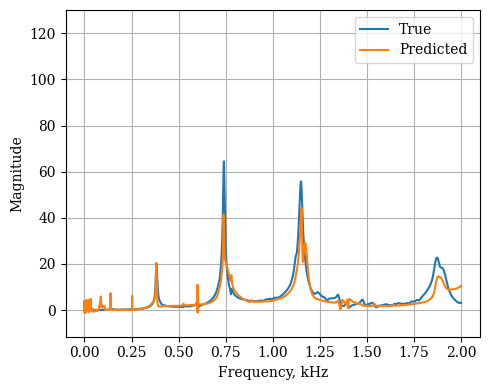

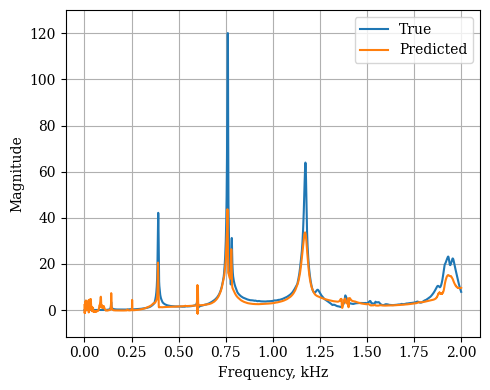

In [15]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Dict, List

import dill
import numpy as np
import torch
import matplotlib.pyplot as plt


# ============================================================
# Paths
# ============================================================
try:
    ROOT = Path(__file__).resolve().parent
except NameError:
    ROOT = Path.cwd()

DATA = ROOT / "frf_data"

FRF_FOLDERS = {
    "healthy": DATA / "1-Beam_healthy",
    "damage_2.96": DATA / "2-Beam_damage_2.96",
    "damage_5.92": DATA / "3-Beam_damage_5.92",
    "damage_8.87": DATA / "4-Beam_damage_8.87",
}

HEALTHY_FOLDER = FRF_FOLDERS["healthy"]
DAMAGED_FOLDER = FRF_FOLDERS["damage_5.92"]

MODEL_PATH = Path("models/frf_model_full.pt")


# ============================================================
# Config (must match training)
# ============================================================
FEATURE_TOKENS: List[str] = ["f", "sin_phase", "cos_phase", "damage"]

DAMAGE_LEVEL = {
    "healthy": 0.0,
    "damage_2.96": 2.96,
    "damage_5.92": 5.92,
    "damage_8.87": 8.87,
}

device = torch.device("cpu")


# ============================================================
# Load model
# ============================================================
ckpt = torch.load(
    MODEL_PATH,
    map_location=device,
    pickle_module=dill,
    weights_only=False,
)

model = ckpt["model"].to(device)
model.eval()

print("Loaded model from:", MODEL_PATH)


# ============================================================
# Robust FRF TXT reader
# ============================================================
_NUM = re.compile(r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?")
_RE_FILE = re.compile(r"^P-(\d+)(?:-(\d+))?$")


def read_frf_txt(path: Path):

    text = path.read_bytes().decode("latin-1", errors="ignore")

    f_list, m_list, p_list = [], [], []

    for line in text.splitlines():

        line = line.strip()
        if not line:
            continue

        nums = _NUM.findall(line)
        if len(nums) < 3:
            continue

        f = float(nums[0])
        mag = float(nums[1])
        ph = float(nums[2])

        if not (np.isfinite(f) and np.isfinite(mag) and np.isfinite(ph)):
            continue

        f_list.append(f)
        m_list.append(mag)
        p_list.append(ph)

    f = np.asarray(f_list)
    mag = np.asarray(m_list)
    ph = np.asarray(p_list)

    idx = np.argsort(f)

    return f[idx], mag[idx], ph[idx]


def parse_file_id(fp: Path):
    m = _RE_FILE.match(fp.stem)
    if not m:
        raise ValueError(f"Unexpected FRF filename: {fp.name}")

    sample = int(m.group(1))
    suffix = int(m.group(2)) if m.group(2) is not None else 0

    return sample, suffix


# ============================================================
# Feature construction (IDENTICAL to training)
# ============================================================
def db_to_linear_mag(mag_db: np.ndarray):

    return np.power(10.0, mag_db / 20.0)


def build_feature_matrix(
    *,
    f: np.ndarray,
    mag_db: np.ndarray,
    ph_deg: np.ndarray,
    cond: str,
):

    phi = np.deg2rad(ph_deg)

    sinp = np.sin(phi)
    cosp = np.cos(phi)

    damage = DAMAGE_LEVEL[cond]

    feature_bank: Dict[str, np.ndarray] = {

        "f": (f / 1000.0).astype(np.float32),

        "sin_phase": sinp.astype(np.float32),

        "cos_phase": cosp.astype(np.float32),

        "damage": np.full_like(f, damage, dtype=np.float32),

    }

    X = np.concatenate(
        [feature_bank[t].reshape(-1, 1) for t in FEATURE_TOKENS],
        axis=1,
    ).astype(np.float32)

    y = db_to_linear_mag(mag_db).astype(np.float32).reshape(-1, 1)

    return X, y


# ============================================================
# Prediction helper
# ============================================================
def predict_curve(fp: Path, cond: str):

    f, mag_db, ph_deg = read_frf_txt(fp)

    X, y_lin = build_feature_matrix(
        f=f,
        mag_db=mag_db,
        ph_deg=ph_deg,
        cond=cond,
    )

    f_idx = FEATURE_TOKENS.index("f")
    f_plot = X[:, f_idx]

    with torch.no_grad():

        Xc = torch.from_numpy(X).float().to(device)

        pred = model(Xc)

        pred_np = pred.detach().cpu().numpy()

        if np.iscomplexobj(pred_np):
            pred_np = pred_np.real

        pred_lin = pred_np.reshape(-1)

    y_lin = y_lin.reshape(-1)

    order = np.argsort(f_plot)

    return f_plot[order], y_lin[order], pred_lin[order]


# ============================================================
# Select files
# ============================================================
healthy_file = sorted(HEALTHY_FOLDER.glob("*.txt"))[0]
damaged_file = sorted(DAMAGED_FOLDER.glob("*.txt"))[0]

print("Healthy file:", healthy_file.name)
print("Damaged file:", damaged_file.name)


# ============================================================
# Predict curves
# ============================================================
f_h, y_h, pred_h = predict_curve(healthy_file, "healthy")
f_d, y_d, pred_d = predict_curve(damaged_file, "damage_5.92")


# ============================================================
# Shared axis limits
# ============================================================
y_min = min(y_h.min(), y_d.min(), pred_h.min(), pred_d.min()) - 10
y_max = max(y_h.max(), y_d.max(), pred_h.max(), pred_d.max()) + 10


# ============================================================
# Plot: Healthy
# ============================================================
import matplotlib as mpl
mpl.rcParams["font.family"] = "serif"

plt.figure(figsize=(5,4))

plt.plot(f_h, y_h, label="True")
plt.plot(f_h, pred_h, label="Predicted")

plt.xlabel("Frequency, kHz")
plt.ylabel("Magnitude")

plt.ylim(y_min, y_max)

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig("figures/frf_prediction_healthy.pdf", bbox_inches="tight")

plt.show()


# ============================================================
# Plot: Damaged
# ============================================================
plt.figure(figsize=(5,4))

plt.plot(f_d, y_d, label="True")
plt.plot(f_d, pred_d, label="Predicted")

plt.xlabel("Frequency, kHz")
plt.ylabel("Magnitude")

plt.ylim(y_min, y_max)

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig("figures/frf_prediction_damaged.pdf", bbox_inches="tight")

plt.show()

# Peak Shift Comparison

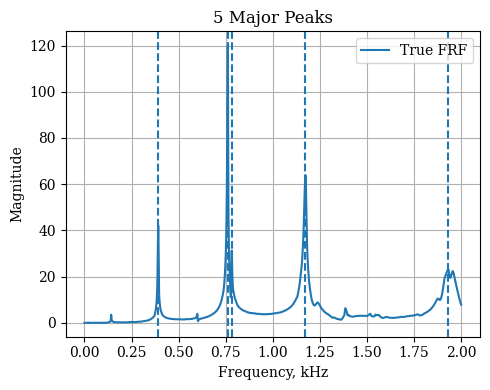

In [16]:
# ============================================================
# Detect major peaks on the TRUE FRF
# ============================================================
from scipy.signal import find_peaks

N_PEAKS = 5

# detect all candidate peaks
peak_idx, _ = find_peaks(y_d)

# sort peaks by amplitude
peak_amplitudes = y_d[peak_idx]
order = np.argsort(peak_amplitudes)[::-1]

# select N largest peaks
top_idx = peak_idx[order[:N_PEAKS]]

# sort them by frequency for nicer plotting
top_idx = np.sort(top_idx)

peak_freqs = f_d[top_idx]
peak_vals = y_d[top_idx]


# ============================================================
# Plot FRF with detected peaks
# ============================================================
plt.figure(figsize=(5,4))

plt.plot(f_d, y_d, label="True FRF")

for f_peak in peak_freqs:
    plt.axvline(f_peak, linestyle="--")

plt.xlabel("Frequency, kHz")
plt.ylabel("Magnitude")
plt.title("5 Major Peaks")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()